# Crop Dataset EDA

Exploratory analysis for crop recommendation features and class distribution.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
ROOT = Path('..').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'crop_recomandation.csv'
OUTPUTS_DIR = ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(RAW_PATH)
target_col = 'label' if 'label' in df.columns else 'Crop'
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'rainfall']
if 'pH' in df.columns:
    numeric_cols.append('pH')
elif 'ph' in df.columns:
    df['pH'] = df['ph']
    numeric_cols.append('pH')

numeric_cols = [c for c in numeric_cols if c in df.columns]
display(df.head())
print('Shape:', df.shape)
display(df[numeric_cols + [target_col]].describe(include='all').T)

,State_Name,Season,N,P,K,rainfall,humidity,temperature,Crop Yield (kg per hectare),Rainfall_Temperature,...,Soil_Type,Irrigation_Method,Fertilizer_Used_kg,Pesticide_Usage_kg,Soil_Moisture,Sunshine_hours,Wind_speed,Altitude_m,Organic_Carbon,Soil_Texture
0,Kerala,Whole Year,41,92,54,2917.102941,66.83,32.60,3324.563123,95097.555877,...,Neutral,Rainfed,170.78,9.58,50.96,4.25,9.55,409.74,0.38,Clay
1,West Bengal,Whole Year,35,9,83,852.525083,48.47,25.67,5471.575701,21884.318891,...,Neutral,Sprinkler,91.18,11.47,35.98,7.19,15.93,310.58,0.63,Clay
2,Assam,Whole Year,42,6,23,1152.740698,76.53,17.61,1734.917776,20299.763692,...,Neutral,Drip,172.09,13.42,48.97,5.79,8.85,10.00,0.86,Sandy
3,Meghalaya,Whole Year,116,37,136,1228.057333,32.12,36.37,4438.622051,44664.445201,...,Neutral,Rainfed,98.29,8.71,25.21,7.06,5.69,412.56,0.54,Loamy
4,Kerala,Whole Year,1,5,54,953.706476,69.97,18.59,2478.063851,17729.403389,...,Neutral,Rainfed,152.09,11.00,46.73,8.63,7.47,521.29,0.82,Clay


Shape: (102675, 25)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,102675.0,NaN,NaN,NaN,71.060823,39.69895,0.0,38.0,68.0,107.0,139.0
P,102675.0,NaN,NaN,NaN,51.502995,26.53518,5.0,28.0,53.0,74.0,99.0
K,102675.0,NaN,NaN,NaN,76.307592,41.479081,5.0,42.0,78.0,112.0,149.0
temperature,102675.0,NaN,NaN,NaN,27.55532,7.175358,15.01,21.82,27.36,33.9,40.0
humidity,102675.0,NaN,NaN,NaN,59.636061,17.049082,30.0,44.52,59.14,73.825,90.0
rainfall,102675.0,NaN,NaN,NaN,1682.253215,789.656256,400.085492,987.094788,1683.347473,2426.116024,2999.630524
pH,102675.0,NaN,NaN,NaN,6.463558,0.604006,4.5,5.96,6.46,6.97,8.0
Crop,102675,111,Arecanut,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1) Univariate Analysis

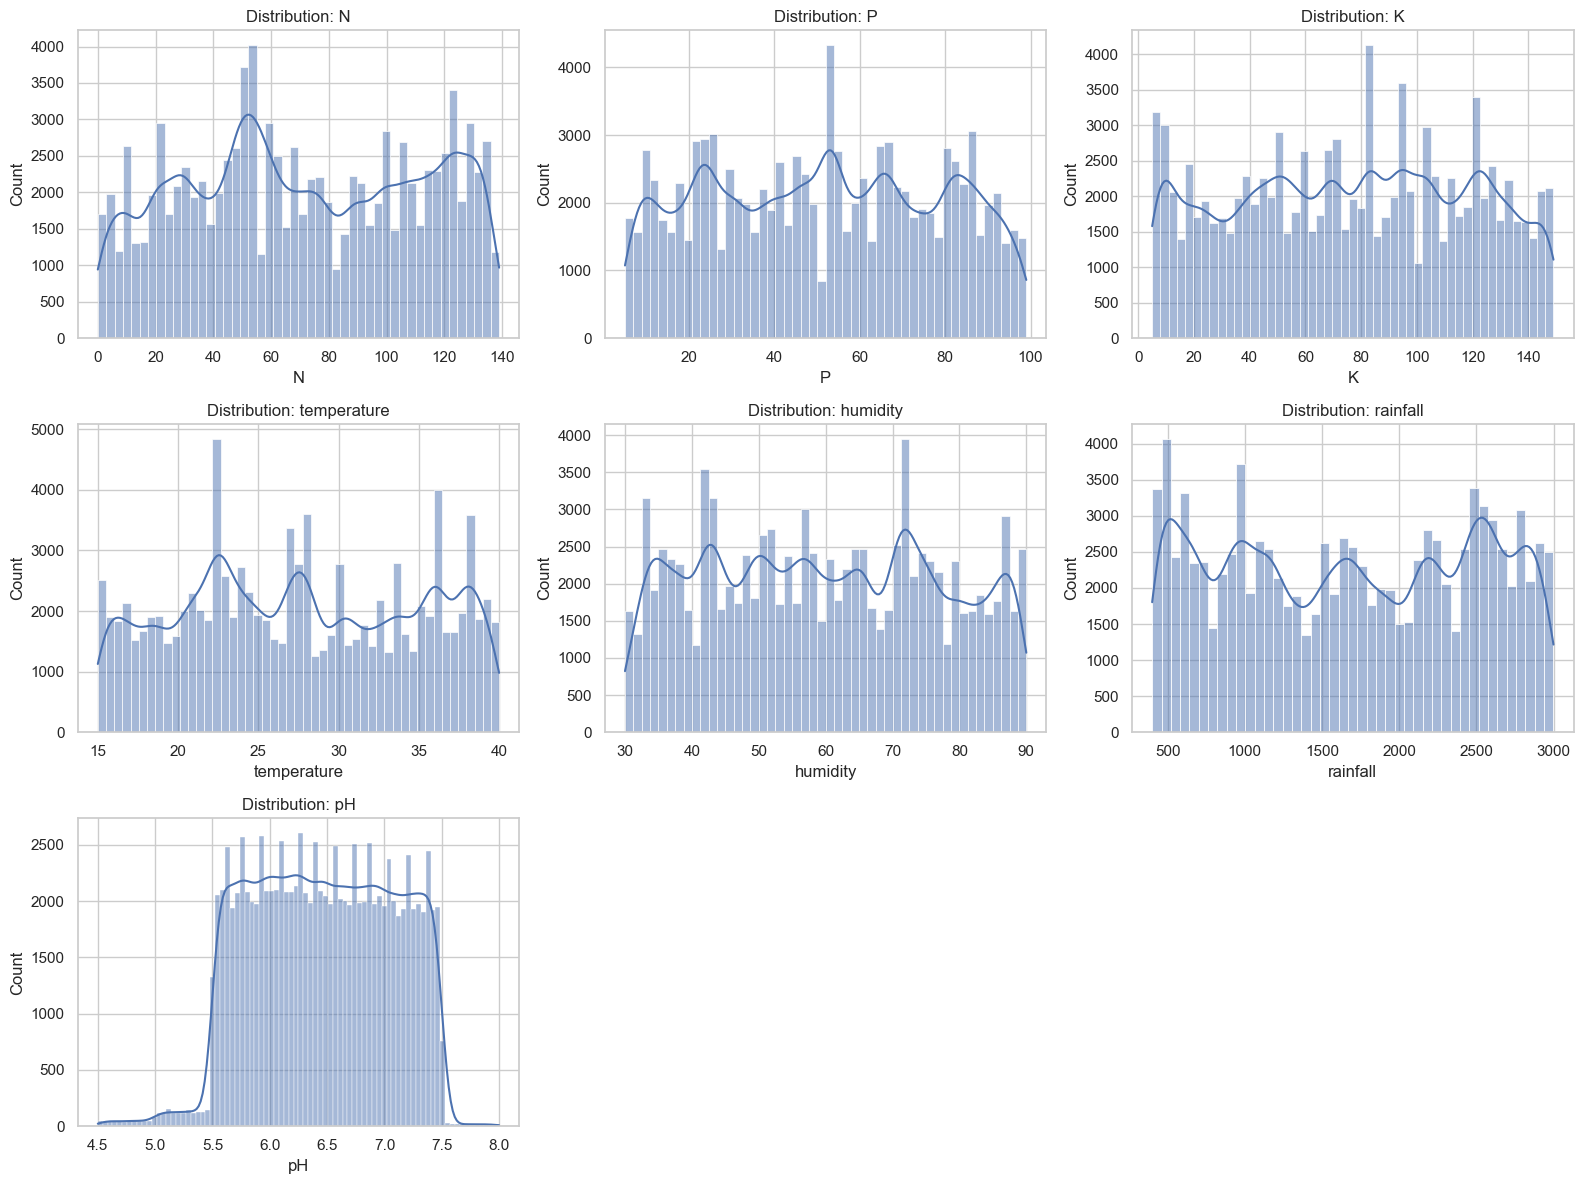

C:\Users\anshb\AppData\Local\Temp\ipykernel_14028\839440096.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index[:20], y=class_counts.values[:20], palette='crest')


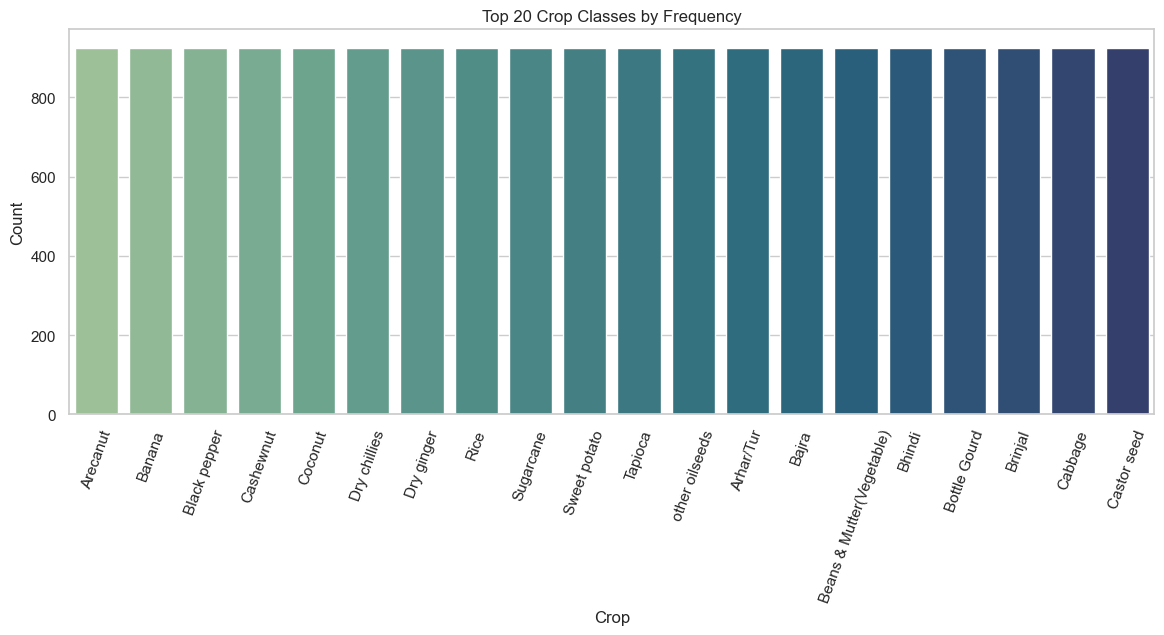

Class imbalance ratio (max/min): 1.0


In [4]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4c72b0')
    axes[i].set_title(f'Distribution: {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
class_counts = df[target_col].value_counts().sort_values(ascending=False)
sns.barplot(x=class_counts.index[:20], y=class_counts.values[:20], palette='crest')
plt.title('Top 20 Crop Classes by Frequency')
plt.xticks(rotation=70)
plt.ylabel('Count')
plt.show()

imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[-1]
print('Class imbalance ratio (max/min):', round(float(imbalance_ratio), 2))

## 2) Bivariate and Multivariate Analysis

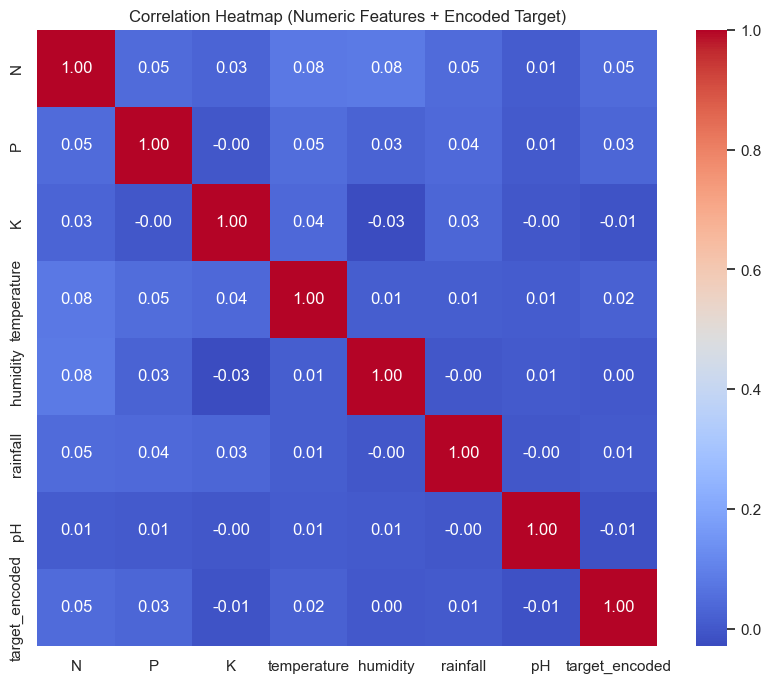

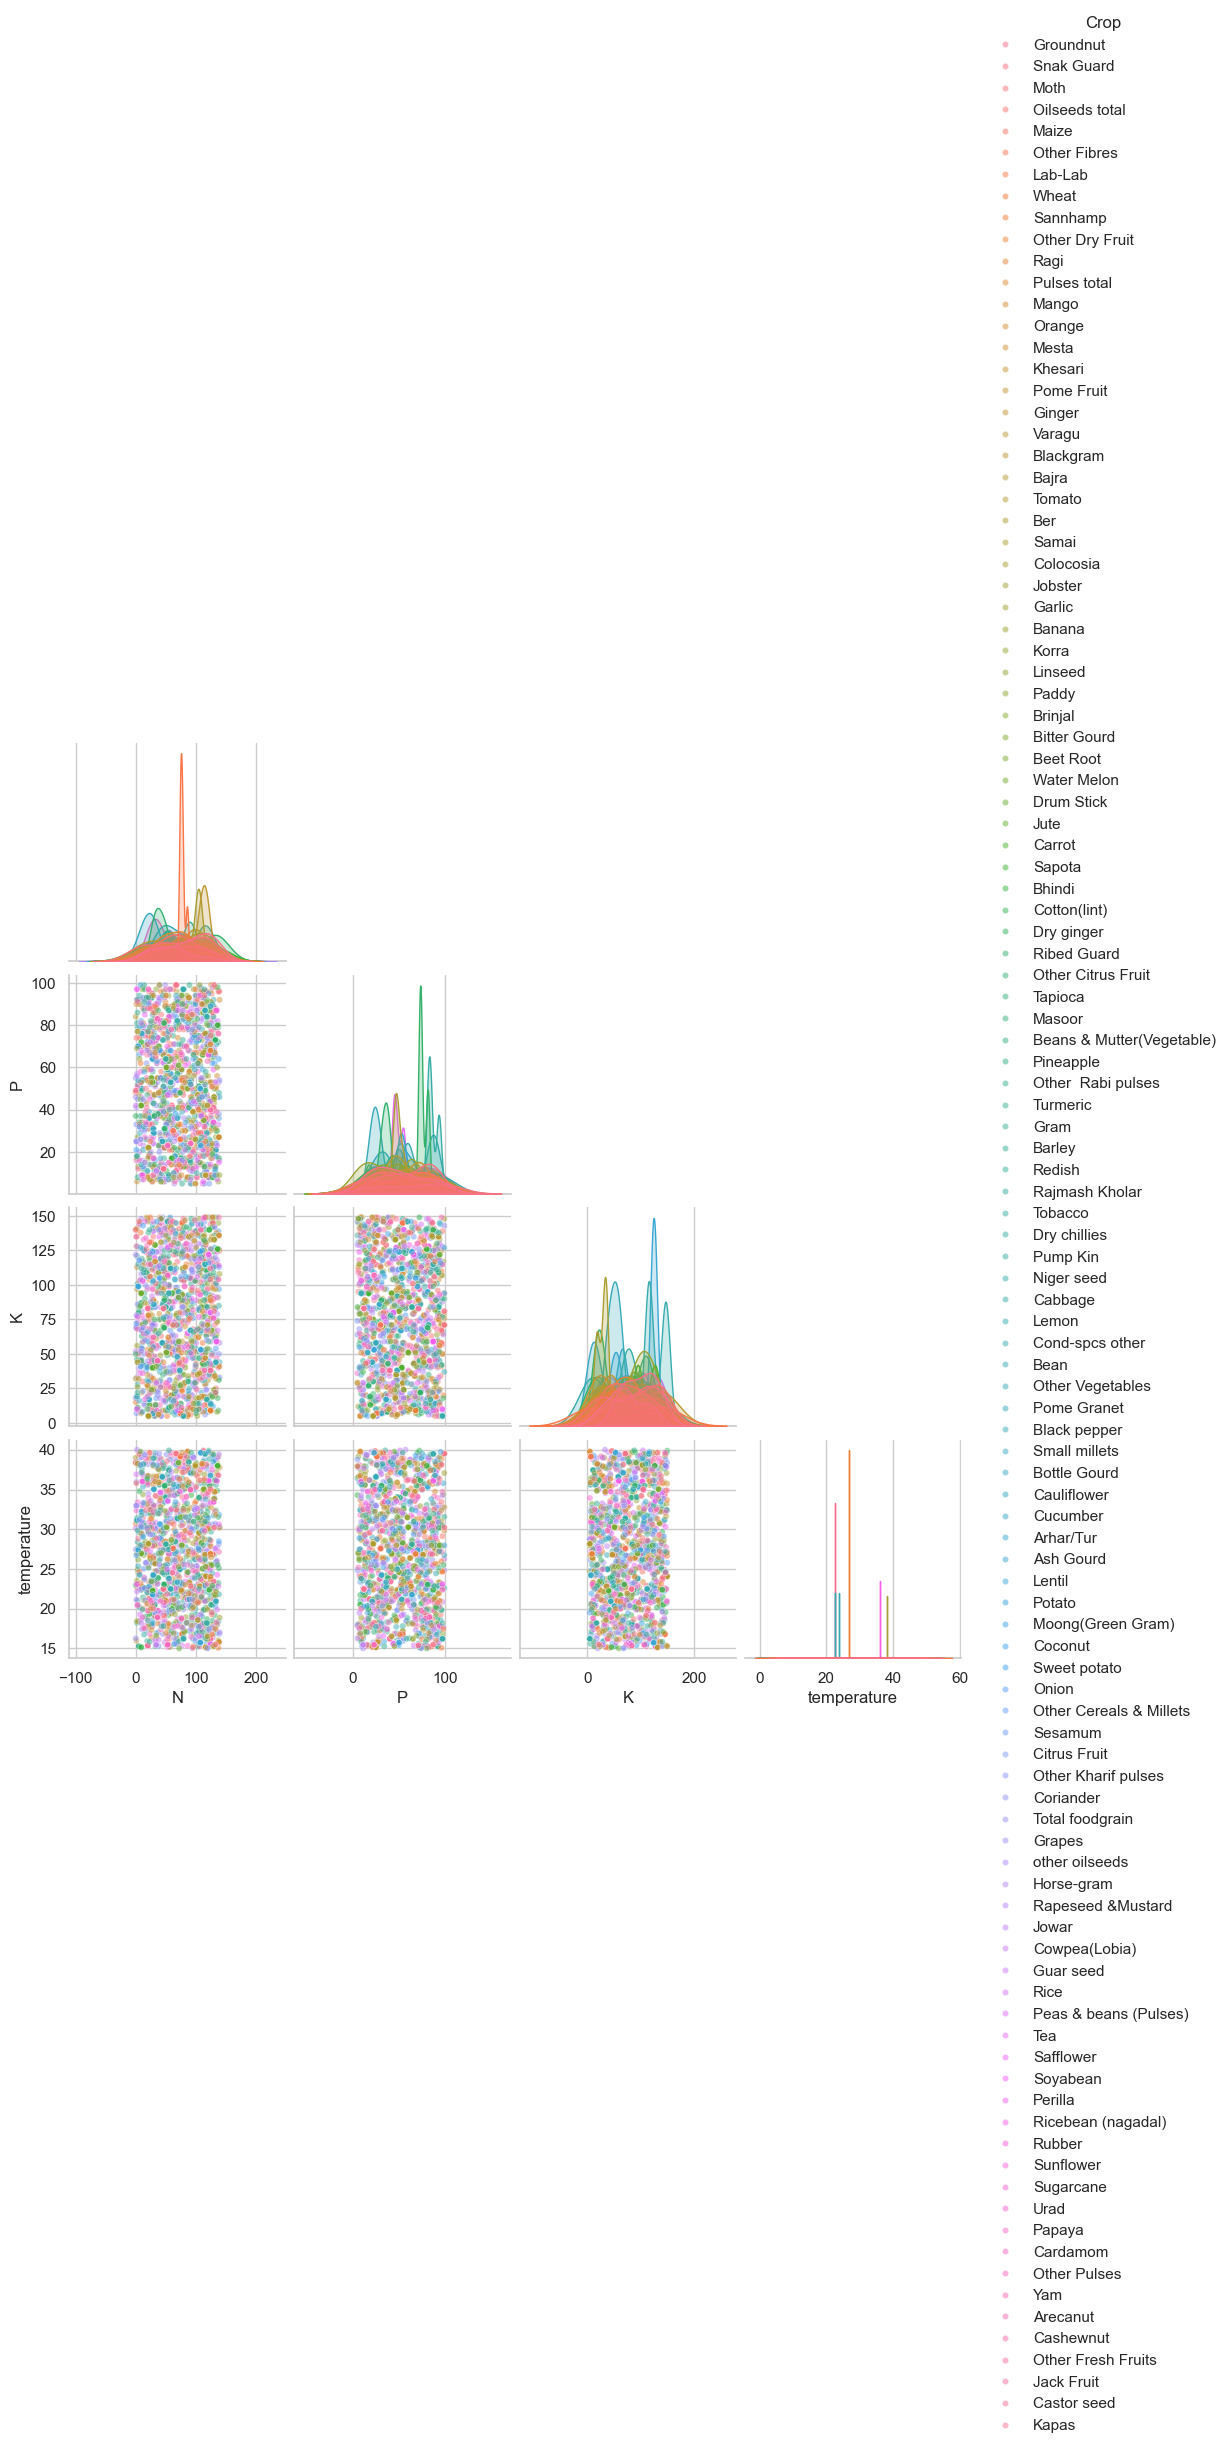

In [5]:
corr_df = df[numeric_cols].copy()
le = LabelEncoder()
corr_df['target_encoded'] = le.fit_transform(df[target_col].astype(str))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features + Encoded Target)')
plt.show()

sample_df = df[numeric_cols + [target_col]].dropna().sample(min(2000, len(df)), random_state=RANDOM_STATE)
sns.pairplot(sample_df, vars=numeric_cols[:4], hue=target_col, corner=True, plot_kws={'alpha': 0.5, 's': 20})
plt.show()

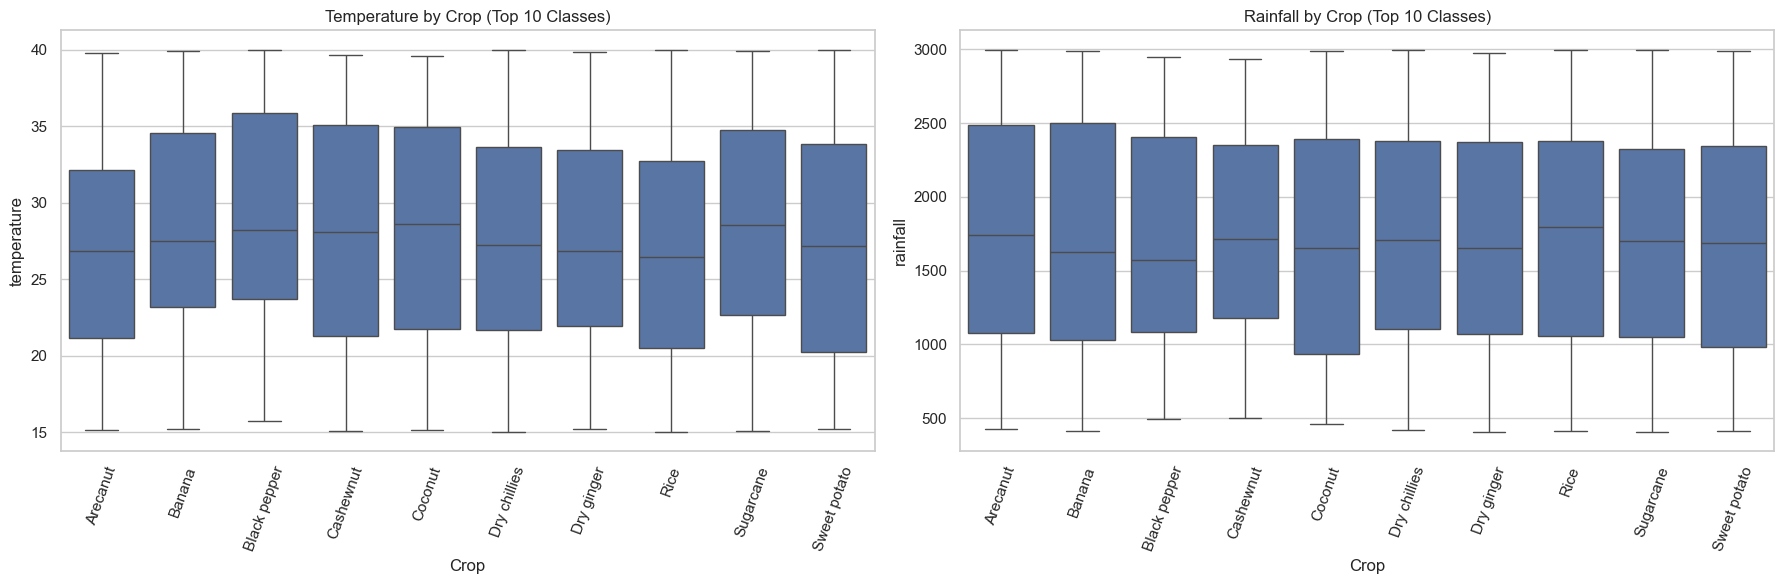

In [6]:
top_classes = class_counts.head(10).index
box_df = df[df[target_col].isin(top_classes)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=box_df, x=target_col, y='temperature', ax=axes[0])
axes[0].set_title('Temperature by Crop (Top 10 Classes)')
axes[0].tick_params(axis='x', rotation=70)

sns.boxplot(data=box_df, x=target_col, y='rainfall', ax=axes[1])
axes[1].set_title('Rainfall by Crop (Top 10 Classes)')
axes[1].tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()

,importance
rainfall,0.184935
humidity,0.177725
temperature,0.170654
K,0.155383
N,0.150922
P,0.140573
pH,0.019810


C:\Users\anshb\AppData\Local\Temp\ipykernel_14028\2700530114.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


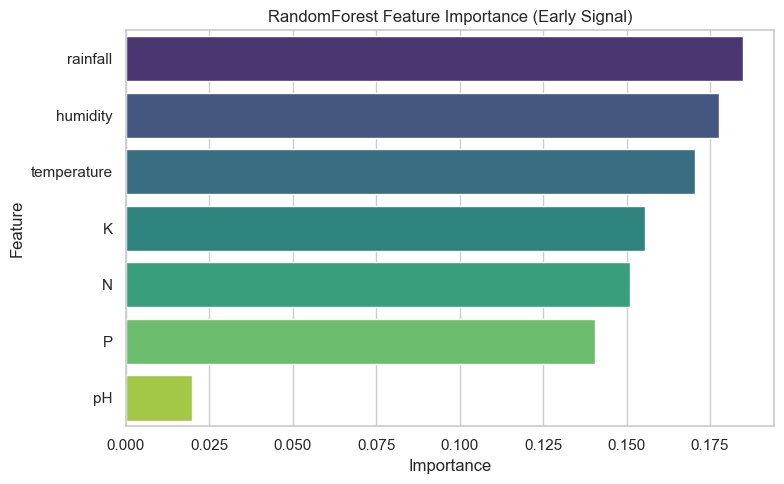

In [7]:
feature_df = df[numeric_cols].copy()
target = LabelEncoder().fit_transform(df[target_col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
display(importances.to_frame('importance'))

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('RandomForest Feature Importance (Early Signal)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importances.to_csv(OUTPUTS_DIR / 'crop_feature_importance.csv')

## Key Insights Summary

- Nutrient features (`N`, `P`, `K`) and weather variables usually provide strong discriminative signal for crop class separation.
- Class-frequency chart highlights imbalance that may require class weighting or resampling during model training.
- Boxplots reveal crop-specific temperature and rainfall bands, useful for interpretable recommendations.
- Correlation and feature-importance outputs should guide feature selection and model diagnostics in training notebooks.